In [2]:
import pandas as pd

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from pathlib import Path

# Paths
BASE = Path(r"C:\Users\Hello\OneDrive\Desktop\Bluestock_internship\bluestock_mf_capstone")
PROCESSED = BASE / "data" / "processed"

# Plot style
sns.set_theme(style="darkgrid")
plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["figure.dpi"] = 100

print("✅ Libraries loaded")

✅ Libraries loaded


In [3]:
# Load required datasets
nav         = pd.read_csv(PROCESSED / "clean_nav.csv", parse_dates=["date"])
performance = pd.read_csv(PROCESSED / "clean_performance.csv")
fund_master = pd.read_csv(PROCESSED / "clean_fund_master.csv")
benchmark   = pd.read_csv(PROCESSED / "clean_benchmark_indices.csv", parse_dates=["date"])

print("✅ Data loaded")
print(f"NAV rows:         {len(nav)}")
print(f"Funds:            {len(fund_master)}")
print(f"Benchmark rows:   {len(benchmark)}")

✅ Data loaded
NAV rows:         64320
Funds:            40
Benchmark rows:   8050


Step 1 — Compute Daily Returns for all funds

In [4]:
# Step 1: Compute daily returns for all funds
nav_pivot = nav.pivot_table(index="date", columns="amfi_code", values="nav")

# Daily return = (today's NAV / yesterday's NAV) - 1
daily_returns = nav_pivot.pct_change().dropna()

print(f"✅ Daily returns computed")
print(f"Shape: {daily_returns.shape}")
print(f"Date range: {daily_returns.index[0]} → {daily_returns.index[-1]}")
print(f"\nSample returns (first 3 funds, first 5 days):")
print(daily_returns.iloc[:5, :3].round(4))

✅ Daily returns computed
Shape: (1607, 40)
Date range: 2022-01-04 00:00:00 → 2026-05-29 00:00:00

Sample returns (first 3 funds, first 5 days):
amfi_code   100016  100025  100033
date                              
2022-01-04 -0.0103 -0.0036 -0.0133
2022-01-05  0.0129 -0.0000 -0.0044
2022-01-06 -0.0114 -0.0019 -0.0052
2022-01-07 -0.0012  0.0020 -0.0057
2022-01-08  0.0000  0.0000  0.0000


Step 2 — Compute CAGR for 1yr, 3yr, 5yr

In [6]:
# Step 2: Compute CAGR for each fund
def compute_cagr(nav_series, years):
    """CAGR = (NAV_end / NAV_start) ^ (1/years) - 1"""
    try:
        end   = nav_series.iloc[-1]
        # Go back approximately n trading days
        n_days = int(years * 252)
        if len(nav_series) < n_days:
            return np.nan
        start = nav_series.iloc[-n_days]
        return (end / start) ** (1 / years) - 1
    except:
        return np.nan

cagr_records = []
for code in nav_pivot.columns:
    series = nav_pivot[code].dropna()
    cagr_records.append({
        "amfi_code"     : code,
        "cagr_1yr_pct"  : round(compute_cagr(series, 1) * 100, 2),
        "cagr_3yr_pct"  : round(compute_cagr(series, 3) * 100, 2),
        "cagr_5yr_pct"  : round(compute_cagr(series, 5) * 100, 2),
    })

cagr_df = pd.DataFrame(cagr_records)

# Merge with fund names
cagr_df = cagr_df.merge(fund_master[["amfi_code", "scheme_name", "fund_house"]], on="amfi_code")

print("✅ CAGR computed")
print(cagr_df[["scheme_name", "cagr_1yr_pct", "cagr_3yr_pct", "cagr_5yr_pct"]].head(10).to_string())

# Save
cagr_df.to_csv(PROCESSED / "cagr_report.csv", index=False)
print("\n✅ cagr_report.csv saved")

✅ CAGR computed
                                          scheme_name  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
0           HDFC Top 100 Fund - Regular Plan - Growth         -4.34         -1.80          3.72
1        HDFC Short Term Debt Fund - Regular - Growth          2.69          4.11          2.92
2  HDFC Mid-Cap Opportunities Fund - Regular - Growth         35.72         24.41         23.11
3       ABSL Frontline Equity Fund - Regular - Growth         37.52         22.40         17.43
4              ABSL Small Cap Fund - Regular - Growth         -9.20         -5.57          1.32
5                 ABSL Liquid Fund - Regular - Growth          5.13          4.34          4.32
6          UTI Nifty 50 Index Fund - Regular - Growth         13.98         13.11         13.16
7                 UTI Mid Cap Fund - Regular - Growth        -20.09         -3.66          1.51
8               UTI Flexi Cap Fund - Regular - Growth         -8.33         17.22         16.36
9      Nippon India Larg

✅ CAGR computed
                                          scheme_name  cagr_1yr_pct  cagr_3yr_pct  cagr_5yr_pct
0           HDFC Top 100 Fund - Regular Plan - Growth         -4.34         -1.80          3.72
1        HDFC Short Term Debt Fund - Regular - Growth          2.69          4.11          2.92
2  HDFC Mid-Cap Opportunities Fund - Regular - Growth         35.72         24.41         23.11
3       ABSL Frontline Equity Fund - Regular - Growth         37.52         22.40         17.43
4              ABSL Small Cap Fund - Regular - Growth         -9.20         -5.57          1.32
5                 ABSL Liquid Fund - Regular - Growth          5.13          4.34          4.32
6          UTI Nifty 50 Index Fund - Regular - Growth         13.98         13.11         13.16
7                 UTI Mid Cap Fund - Regular - Growth        -20.09         -3.66          1.51
8               UTI Flexi Cap Fund - Regular - Growth         -8.33         17.22         16.36
9      Nippon India Large Cap Fund - Regular - Growth         18.21         13.18         17.22

✅ cagr_report.csv saved

In [7]:
# Step 3: Compute Sharpe Ratio
# Sharpe = (Rp - Rf) / Std(Rp) * sqrt(252)
# Rf = 6.5% annual = 6.5/252/100 daily

Rf_daily = 6.5 / 252 / 100

sharpe_records = []
for code in daily_returns.columns:
    r = daily_returns[code].dropna()
    excess_return = r - Rf_daily
    sharpe = (excess_return.mean() / excess_return.std()) * np.sqrt(252)
    sharpe_records.append({
        "amfi_code"   : code,
        "sharpe_ratio": round(sharpe, 4)
    })

sharpe_df = pd.DataFrame(sharpe_records)
sharpe_df = sharpe_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")

print("✅ Sharpe Ratio computed")
print(sharpe_df[["scheme_name", "sharpe_ratio"]].sort_values("sharpe_ratio", ascending=False).head(10).to_string())

# Save
sharpe_df.to_csv(PROCESSED / "sharpe_values.csv", index=False)
print("\n✅ sharpe_values.csv saved")

✅ Sharpe Ratio computed
                                           scheme_name  sharpe_ratio
34       Mirae Asset Large Cap Fund - Regular - Growth        1.0682
30              Kotak Flexicap Fund - Regular - Growth        0.9656
36       Mirae Asset Tax Saver Fund - Regular - Growth        0.9190
25            ICICI Pru Midcap Fund - Regular - Growth        0.8833
19           SBI Bluechip Fund - Regular Plan - Growth        0.8610
38                  DSP Midcap Fund - Regular - Growth        0.8329
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth        0.8083
9       Nippon India Large Cap Fund - Regular - Growth        0.7589
16                 Axis Midcap Fund - Regular - Growth        0.7305
3        ABSL Frontline Equity Fund - Regular - Growth        0.7174

✅ sharpe_values.csv saved


Step 4 — Compute Sortino Ratio

In [8]:
# Step 4: Compute Sortino Ratio
# Sortino = (Rp - Rf) / Downside_Std * sqrt(252)
# Downside Std = std of ONLY negative return days

sortino_records = []
for code in daily_returns.columns:
    r = daily_returns[code].dropna()
    excess_return = r - Rf_daily
    # Only negative returns for downside std
    downside = excess_return[excess_return < 0]
    downside_std = downside.std()
    sortino = (excess_return.mean() / downside_std) * np.sqrt(252)
    sortino_records.append({
        "amfi_code"    : code,
        "sortino_ratio": round(sortino, 4)
    })

sortino_df = pd.DataFrame(sortino_records)
sortino_df = sortino_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")

print("✅ Sortino Ratio computed")
print(sortino_df[["scheme_name", "sortino_ratio"]].sort_values("sortino_ratio", ascending=False).head(10).to_string())

# Save
sortino_df.to_csv(PROCESSED / "sortino_values.csv", index=False)
print("\n✅ sortino_values.csv saved")

✅ Sortino Ratio computed
                                           scheme_name  sortino_ratio
34       Mirae Asset Large Cap Fund - Regular - Growth         1.5548
30              Kotak Flexicap Fund - Regular - Growth         1.4859
36       Mirae Asset Tax Saver Fund - Regular - Growth         1.3870
25            ICICI Pru Midcap Fund - Regular - Growth         1.3211
19           SBI Bluechip Fund - Regular Plan - Growth         1.3025
38                  DSP Midcap Fund - Regular - Growth         1.2018
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth         1.1844
9       Nippon India Large Cap Fund - Regular - Growth         1.1215
16                 Axis Midcap Fund - Regular - Growth         1.0915
3        ABSL Frontline Equity Fund - Regular - Growth         1.0788

✅ sortino_values.csv saved


Step 5 — Compute Alpha & Beta

In [9]:
# Step 5: Compute Alpha & Beta vs Nifty 100
# Beta = slope of regression (fund returns vs benchmark returns)
# Alpha = intercept * 252 (annualised)

# Get Nifty 100 daily returns
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].copy()
nifty100 = nifty100.set_index("date")["close_value"].pct_change().dropna()
nifty100.name = "nifty100"

alpha_beta_records = []
for code in daily_returns.columns:
    fund_r = daily_returns[code].dropna()

    # Align dates
    aligned = pd.concat([fund_r, nifty100], axis=1).dropna()
    if len(aligned) < 100:
        continue

    slope, intercept, r_value, p_value, std_err = stats.linregress(
        aligned["nifty100"], aligned[code]
    )

    alpha_beta_records.append({
        "amfi_code": code,
        "beta"     : round(slope, 4),
        "alpha_ann": round(intercept * 252 * 100, 4),  # annualised %
        "r_squared": round(r_value ** 2, 4)
    })

ab_df = pd.DataFrame(alpha_beta_records)
ab_df = ab_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")

print("✅ Alpha & Beta computed")
print(ab_df[["scheme_name", "beta", "alpha_ann", "r_squared"]].sort_values("alpha_ann", ascending=False).head(10).to_string())

# Save
ab_df.to_csv(PROCESSED / "alpha_beta.csv", index=False)
print("\n✅ alpha_beta.csv saved")

✅ Alpha & Beta computed
                                           scheme_name    beta  alpha_ann  r_squared
21          SBI Small Cap Fund - Regular Plan - Growth -0.0232    30.3370     0.0001
39               DSP Small Cap Fund - Regular - Growth  0.0115    30.0579     0.0000
25            ICICI Pru Midcap Fund - Regular - Growth  0.0005    29.2636     0.0000
36       Mirae Asset Tax Saver Fund - Regular - Growth  0.0181    28.2704     0.0002
30              Kotak Flexicap Fund - Regular - Growth -0.0228    27.3305     0.0003
2   HDFC Mid-Cap Opportunities Fund - Regular - Growth  0.0051    27.1954     0.0000
34       Mirae Asset Large Cap Fund - Regular - Growth  0.0237    26.9838     0.0005
38                  DSP Midcap Fund - Regular - Growth -0.0025    26.5986     0.0000
16                 Axis Midcap Fund - Regular - Growth -0.0663    26.0767     0.0019
19           SBI Bluechip Fund - Regular Plan - Growth -0.0318    23.2010     0.0009

✅ alpha_beta.csv saved


Step 6 — Compute Maximum Drawdown

In [10]:
# Step 6: Compute Maximum Drawdown
# Max Drawdown = worst peak-to-trough decline

drawdown_records = []
for code in nav_pivot.columns:
    series = nav_pivot[code].dropna()

    # Running maximum (peak)
    running_max = series.cummax()

    # Drawdown at each point
    drawdown = (series - running_max) / running_max

    # Maximum drawdown
    max_dd = drawdown.min()

    drawdown_records.append({
        "amfi_code"      : code,
        "max_drawdown_pct": round(max_dd * 100, 2)
    })

dd_df = pd.DataFrame(drawdown_records)
dd_df = dd_df.merge(fund_master[["amfi_code", "scheme_name"]], on="amfi_code")

print("✅ Maximum Drawdown computed")
print(dd_df[["scheme_name", "max_drawdown_pct"]].sort_values("max_drawdown_pct").head(10).to_string())

# Save
dd_df.to_csv(PROCESSED / "max_drawdown.csv", index=False)
print("\n✅ max_drawdown.csv saved")

✅ Maximum Drawdown computed
                                       scheme_name  max_drawdown_pct
22       SBI Small Cap Fund - Direct Plan - Growth            -52.57
17          Axis Small Cap Fund - Regular - Growth            -51.68
4           ABSL Small Cap Fund - Regular - Growth            -35.45
39           DSP Small Cap Fund - Regular - Growth            -31.17
21      SBI Small Cap Fund - Regular Plan - Growth            -28.71
7              UTI Mid Cap Fund - Regular - Growth            -28.00
0        HDFC Top 100 Fund - Regular Plan - Growth            -24.73
29   Kotak Emerging Equity Fund - Regular - Growth            -24.00
11  Nippon India Small Cap Fund - Regular - Growth            -23.34
15            Axis Bluechip Fund - Direct - Growth            -21.75

✅ max_drawdown.csv saved


Step 7 — Build Fund Scorecard

In [11]:
# Step 7: Fund Scorecard (composite score 0-100)
# Score = 30%×(3yr return rank) + 25%×(Sharpe rank) + 
#         20%×(Alpha rank) + 15%×(Expense ratio rank, inverse) + 
#         10%×(Max DD rank, inverse)

# Merge all metrics
scorecard = fund_master[["amfi_code", "scheme_name", "fund_house", 
                          "category", "expense_ratio_pct"]].copy()
scorecard = scorecard.merge(cagr_df[["amfi_code", "cagr_3yr_pct"]], on="amfi_code")
scorecard = scorecard.merge(sharpe_df[["amfi_code", "sharpe_ratio"]], on="amfi_code")
scorecard = scorecard.merge(ab_df[["amfi_code", "alpha_ann"]], on="amfi_code")
scorecard = scorecard.merge(dd_df[["amfi_code", "max_drawdown_pct"]], on="amfi_code")

# Rank each metric (higher rank = better)
n = len(scorecard)
scorecard["rank_3yr"]     = scorecard["cagr_3yr_pct"].rank()
scorecard["rank_sharpe"]  = scorecard["sharpe_ratio"].rank()
scorecard["rank_alpha"]   = scorecard["alpha_ann"].rank()
scorecard["rank_expense"] = scorecard["expense_ratio_pct"].rank(ascending=False)  # lower is better
scorecard["rank_maxdd"]   = scorecard["max_drawdown_pct"].rank(ascending=False)   # less negative is better

# Composite score
scorecard["score"] = (
    0.30 * scorecard["rank_3yr"] +
    0.25 * scorecard["rank_sharpe"] +
    0.20 * scorecard["rank_alpha"] +
    0.15 * scorecard["rank_expense"] +
    0.10 * scorecard["rank_maxdd"]
)

# Normalise to 0-100
scorecard["score"] = ((scorecard["score"] - scorecard["score"].min()) /
                      (scorecard["score"].max() - scorecard["score"].min()) * 100).round(2)

# Sort by score
scorecard = scorecard.sort_values("score", ascending=False).reset_index(drop=True)

print("✅ Fund Scorecard computed")
print(scorecard[["scheme_name", "score", "cagr_3yr_pct", "sharpe_ratio"]].head(10).to_string())

# Save
scorecard.to_csv(PROCESSED / "fund_scorecard.csv", index=False)
print("\n✅ fund_scorecard.csv saved")

✅ Fund Scorecard computed
                                          scheme_name   score  cagr_3yr_pct  sharpe_ratio
0  HDFC Mid-Cap Opportunities Fund - Regular - Growth  100.00         24.41        0.8083
1       Mirae Asset Large Cap Fund - Regular - Growth   99.16         25.13        1.0682
2            ICICI Pru Midcap Fund - Regular - Growth   97.69         15.72        0.8833
3              Kotak Flexicap Fund - Regular - Growth   97.48         21.67        0.9656
4          SBI Small Cap Fund - Regular Plan - Growth   95.80         18.93        0.7117
5                 Axis Midcap Fund - Regular - Growth   94.96         21.29        0.7305
6           SBI Bluechip Fund - Regular Plan - Growth   92.75         28.56        0.8610
7               DSP Small Cap Fund - Regular - Growth   90.44         17.05        0.7144
8       Mirae Asset Tax Saver Fund - Regular - Growth   88.97         20.89        0.9190
9                  DSP Midcap Fund - Regular - Growth   88.24         24.6

Step 8 — Benchmark Comparison Chart

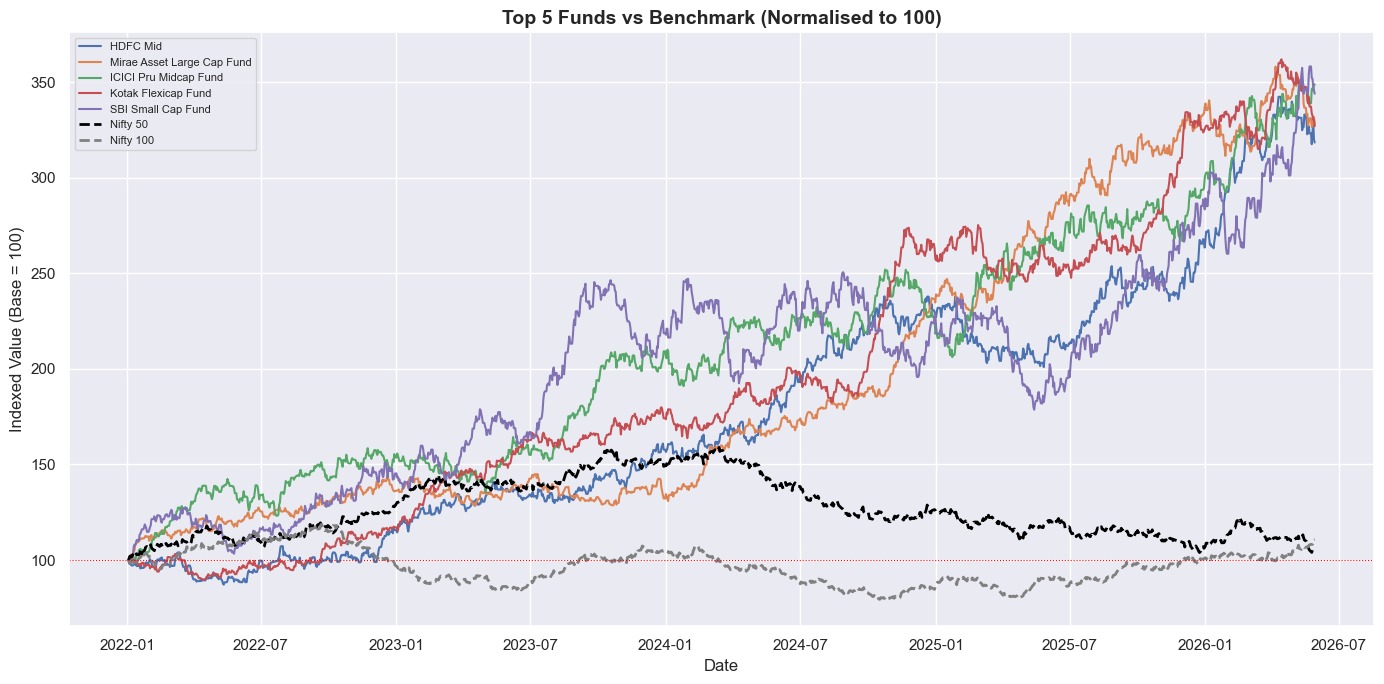

✅ Benchmark chart saved


In [12]:
# Step 8: Benchmark Comparison Chart
# Top 5 funds vs Nifty 50 and Nifty 100

top5_codes = scorecard.head(5)["amfi_code"].tolist()
top5_names = scorecard.head(5).set_index("amfi_code")["scheme_name"].to_dict()

# Get Nifty 50 and Nifty 100
nifty50  = benchmark[benchmark["index_name"] == "NIFTY50"].set_index("date")["close_value"]
nifty100 = benchmark[benchmark["index_name"] == "NIFTY100"].set_index("date")["close_value"]

fig, ax = plt.subplots(figsize=(14, 7))

# Plot top 5 funds (normalised to 100)
for code in top5_codes:
    series = nav_pivot[code].dropna()
    normalised = series / series.iloc[0] * 100
    short_name = top5_names[code].split("-")[0].strip()
    ax.plot(normalised.index, normalised, linewidth=1.5, label=short_name)

# Plot benchmarks
n50  = nifty50  / nifty50.iloc[0]  * 100
n100 = nifty100 / nifty100.iloc[0] * 100
ax.plot(n50.index,  n50,  linewidth=2, linestyle="--", color="black",  label="Nifty 50")
ax.plot(n100.index, n100, linewidth=2, linestyle="--", color="gray",   label="Nifty 100")

ax.set_title("Top 5 Funds vs Benchmark (Normalised to 100)", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Indexed Value (Base = 100)")
ax.legend(fontsize=8)
ax.axhline(100, color="red", linestyle=":", linewidth=0.8)
plt.tight_layout()
plt.savefig(PROCESSED / "benchmark_chart.png", dpi=150)
plt.show()
print("✅ Benchmark chart saved")

Step 9 — Rolling Sharpe Chart

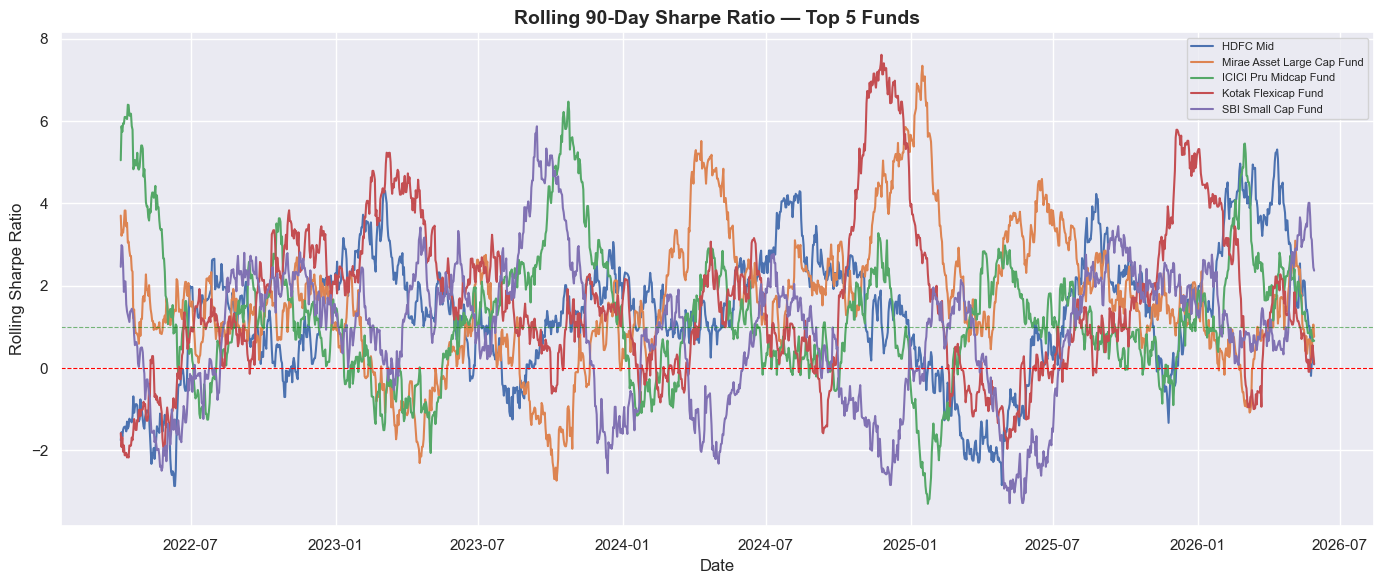

✅ Rolling Sharpe chart saved


In [13]:
# Step 9: Rolling 90-day Sharpe Ratio for top 5 funds
fig, ax = plt.subplots(figsize=(14, 6))

for code in top5_codes:
    r = daily_returns[code].dropna()
    rolling_sharpe = (r.rolling(90).mean() / r.rolling(90).std()) * np.sqrt(252)
    short_name = top5_names[code].split("-")[0].strip()
    ax.plot(rolling_sharpe.index, rolling_sharpe, linewidth=1.5, label=short_name)

ax.axhline(0, color="red", linestyle="--", linewidth=0.8)
ax.axhline(1, color="green", linestyle="--", linewidth=0.8, alpha=0.5)
ax.set_title("Rolling 90-Day Sharpe Ratio — Top 5 Funds", fontsize=14, fontweight="bold")
ax.set_xlabel("Date")
ax.set_ylabel("Rolling Sharpe Ratio")
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig(PROCESSED / "rolling_sharpe_chart.png", dpi=150)
plt.show()
print("✅ Rolling Sharpe chart saved")